Import libraries

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Load data

In [13]:
data = pd.read_csv("Churn_in_telecoms_dataset.csv")
data.head

<bound method NDFrame.head of      state  account length  area code phone number international plan  \
0       KS             128        415     382-4657                 no   
1       OH             107        415     371-7191                 no   
2       NJ             137        415     358-1921                 no   
3       OH              84        408     375-9999                yes   
4       OK              75        415     330-6626                yes   
...    ...             ...        ...          ...                ...   
3328    AZ             192        415     414-4276                 no   
3329    WV              68        415     370-3271                 no   
3330    RI              28        510     328-8230                 no   
3331    CT             184        510     364-6381                yes   
3332    TN              74        415     400-4344                 no   

     voice mail plan  number vmail messages  total day minutes  \
0                yes       

More data descriptives

In [14]:
data.columns

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [16]:
data.value_counts()

state  account length  area code  phone number  international plan  voice mail plan  number vmail messages  total day minutes  total day calls  total day charge  total eve minutes  total eve calls  total eve charge  total night minutes  total night calls  total night charge  total intl minutes  total intl calls  total intl charge  customer service calls  churn
AK     1               408        373-1028      no                  no               0                      175.2              74               29.78             151.7              79               12.89             230.5                109                10.37               5.3                 3                 1.43               1                       False    1
NV     87              510        331-8484      no                  yes              39                     82.6               113              14.04             224.4              63               19.07             163.6                88                 7.36         

**Observations:**
- 21 columns in the dataset 
- no null values
- Data cleaning not necessary 

# EDA

Analysis 1: International Plan vs Churn

Text(0.5, 0, 'International Plan')

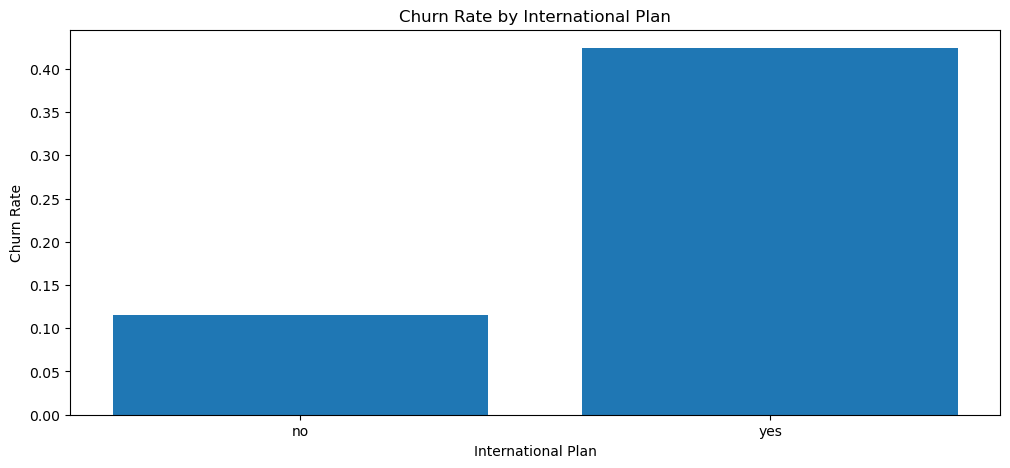

In [17]:
churn_rate = data.groupby('international plan')['churn'].mean()

# Plot with Matplotlib

plt.figure(figsize=(12,5))
plt.bar(churn_rate.index, churn_rate.values)
plt.title('Churn Rate by International Plan')
plt.ylabel('Churn Rate')
plt.xlabel('International Plan')

Analysis 2: Customer Service Calls vs Churn

Text(0, 0.5, 'Mean Number of Customer Service Calls')

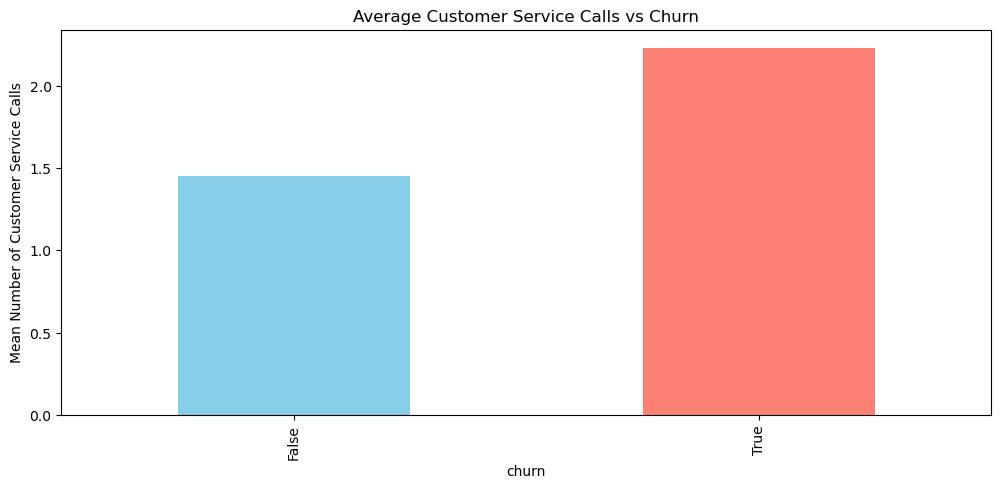

In [18]:
mean_calls = data.groupby('churn')['customer service calls'].mean()

plt.figure(figsize=(12,5))
mean_calls.plot(kind='bar', color=['skyblue','salmon'])
plt.title('Average Customer Service Calls vs Churn')
plt.ylabel('Mean Number of Customer Service Calls')

Analysis 3: Customer Service Calls vs Total Day Charge

In [19]:
data.groupby('churn')['total day charge'].mean()

churn
False    29.780421
True     35.175921
Name: total day charge, dtype: float64

Text(0.5, 1.0, 'Customer Service Calls vs Total Day Charge')

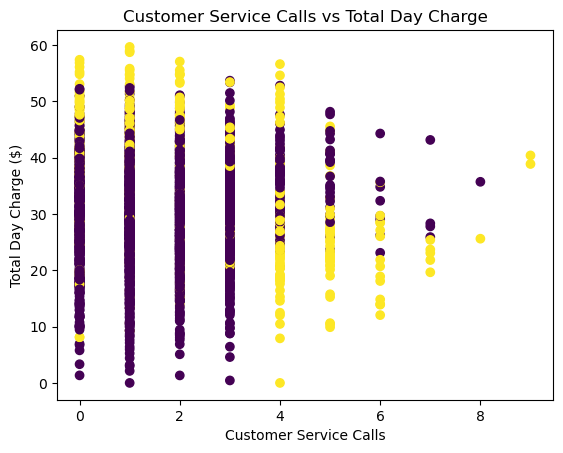

In [20]:
plt.scatter(data['customer service calls'], data['total day charge'], c=data['churn'])
plt.xlabel('Customer Service Calls')
plt.ylabel('Total Day Charge ($)')
plt.title('Customer Service Calls vs Total Day Charge')

### Summary:

Having loaded the dataset, and running some descriptives, it was evident that there is need for data cleaning since there were no missing values. The datatypes were clar as well.